# Academic Stress and Student Well-being

## Project purpose

This notebook begins a reproducible investigation of student stress factors. The immediate goal is **data understanding**, not machine-learning performance. We first establish what the rows and variables represent, verify data quality, document important encodings, and explore one relationship carefully.

### Working exploratory question

> **How does the distribution of stress level differ between students who report a mental-health history and those who do not?**

This wording asks about an **association** in this dataset. It does not claim that mental-health history causes stress.

### Data provenance

- Dataset: [Student Stress Factors: A Comprehensive Analysis](https://www.kaggle.com/datasets/rxnach/student-stress-factors-a-comprehensive-analysis/data)
- Related research article: [Foysal et al. (2024)](https://link.springer.com/article/10.1007/s44163-024-00169-6)
- Authors' analysis notebook: [Stress-analysis repository](https://github.com/Foysal-A-Al/Stress-analysis/blob/main/Stress_analysis.ipynb)

The raw CSV is kept unchanged. Analysis is performed on copies so that cleaning or labeling decisions remain reversible.

## 1. Load and identify the dataset

The path logic below lets the notebook run from either the repository root or the `notebooks/` directory. The assertion fails early with a useful message if the dataset is missing.

In [1]:
from pathlib import Path
import hashlib

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd()

# This works whether the notebook starts in the repository root
# or inside the notebooks directory.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "StressLevelDataset.csv"

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

DATA_PATH.relative_to(PROJECT_ROOT)

WindowsPath('data/raw/StressLevelDataset.csv')

### Reproducibility check

A SHA-256 hash is a fingerprint of the exact CSV file. If the data file changes later, its hash changes too. Recording the hash helps us distinguish a real analytical change from an unnoticed data-version change.

In [2]:
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

print(f"File: {DATA_PATH.name}")
print(f"SHA-256: {file_hash}")

File: StressLevelDataset.csv
SHA-256: 14a45e92708b0c063ad4ab04563aa8fd4e3fc27157fd282e1c0658dc5161faed


In [3]:
df_raw = pd.read_csv(DATA_PATH)

# All later work will use a copy.
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 1,100
Columns: 21


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


**Initial observation:** the dataset contains **1,100 students and 21 variables**. Each row represents one student record. The first rows show that the variables are stored numerically, but an integer data type alone does not prove that every variable is a continuous measurement. Some integers may be category codes or ordered ratings.

## 2. Structure and data-quality checks

We inspect data types, missingness, the number of distinct values, observed ranges, and duplicate rows. These checks answer different questions:

- **Data type:** how pandas currently stores the values.
- **Unique values and range:** clues about whether a variable is continuous, binary, or ordinal.
- **Missing values:** whether a missing-data strategy is needed.
- **Duplicate rows:** whether identical records may have been included more than once.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [5]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=False),
    "minimum": df.min(),
    "maximum": df.max(),
})

quality_summary

,dtype,missing_count,missing_percent,unique_values,minimum,maximum
anxiety_level,int64,0,0.0,22,0,21
self_esteem,int64,0,0.0,31,0,30
mental_health_history,int64,0,0.0,2,0,1
depression,int64,0,0.0,28,0,27
headache,int64,0,0.0,6,0,5
blood_pressure,int64,0,0.0,3,1,3
sleep_quality,int64,0,0.0,6,0,5
breathing_problem,int64,0,0.0,6,0,5
noise_level,int64,0,0.0,6,0,5
living_conditions,int64,0,0.0,6,0,5


In [6]:
duplicate_count = int(df.duplicated().sum())

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


### Data-quality result

- All 21 columns are stored as integers.
- There are **no missing values** and **no fully duplicated rows**.
- `mental_health_history` has two values (`0` and `1`), so it is a binary coded variable.
- `stress_level` has three values (`0`, `1`, and `2`), so it is a three-class coded outcome.
- Several variables use only `0`–`5`. These are likely coded rating scales, but their direction and wording should not be guessed without documentation.

No missing or duplicated rows is convenient, but it does **not** by itself establish that the measurements are valid or representative.

## 3. Explore low-cardinality coded variables

The following bar charts show how frequently each recorded code occurs. They are useful for finding rare codes, imbalance, and unusual patterns.

Important distinctions:

- A balanced variable can still be strongly associated with the outcome. Therefore, the nearly equal sizes of the two mental-health-history groups do not make that variable unhelpful.
- A roughly bell-shaped bar pattern does not prove that a variable is a good measurement. Measurement quality depends on the survey question, scale construction, reliability, and validity—not only its distribution.
- Until a codebook is verified, values such as `0`–`5` should be described as **recorded codes**, not automatically as “low” or “high.”

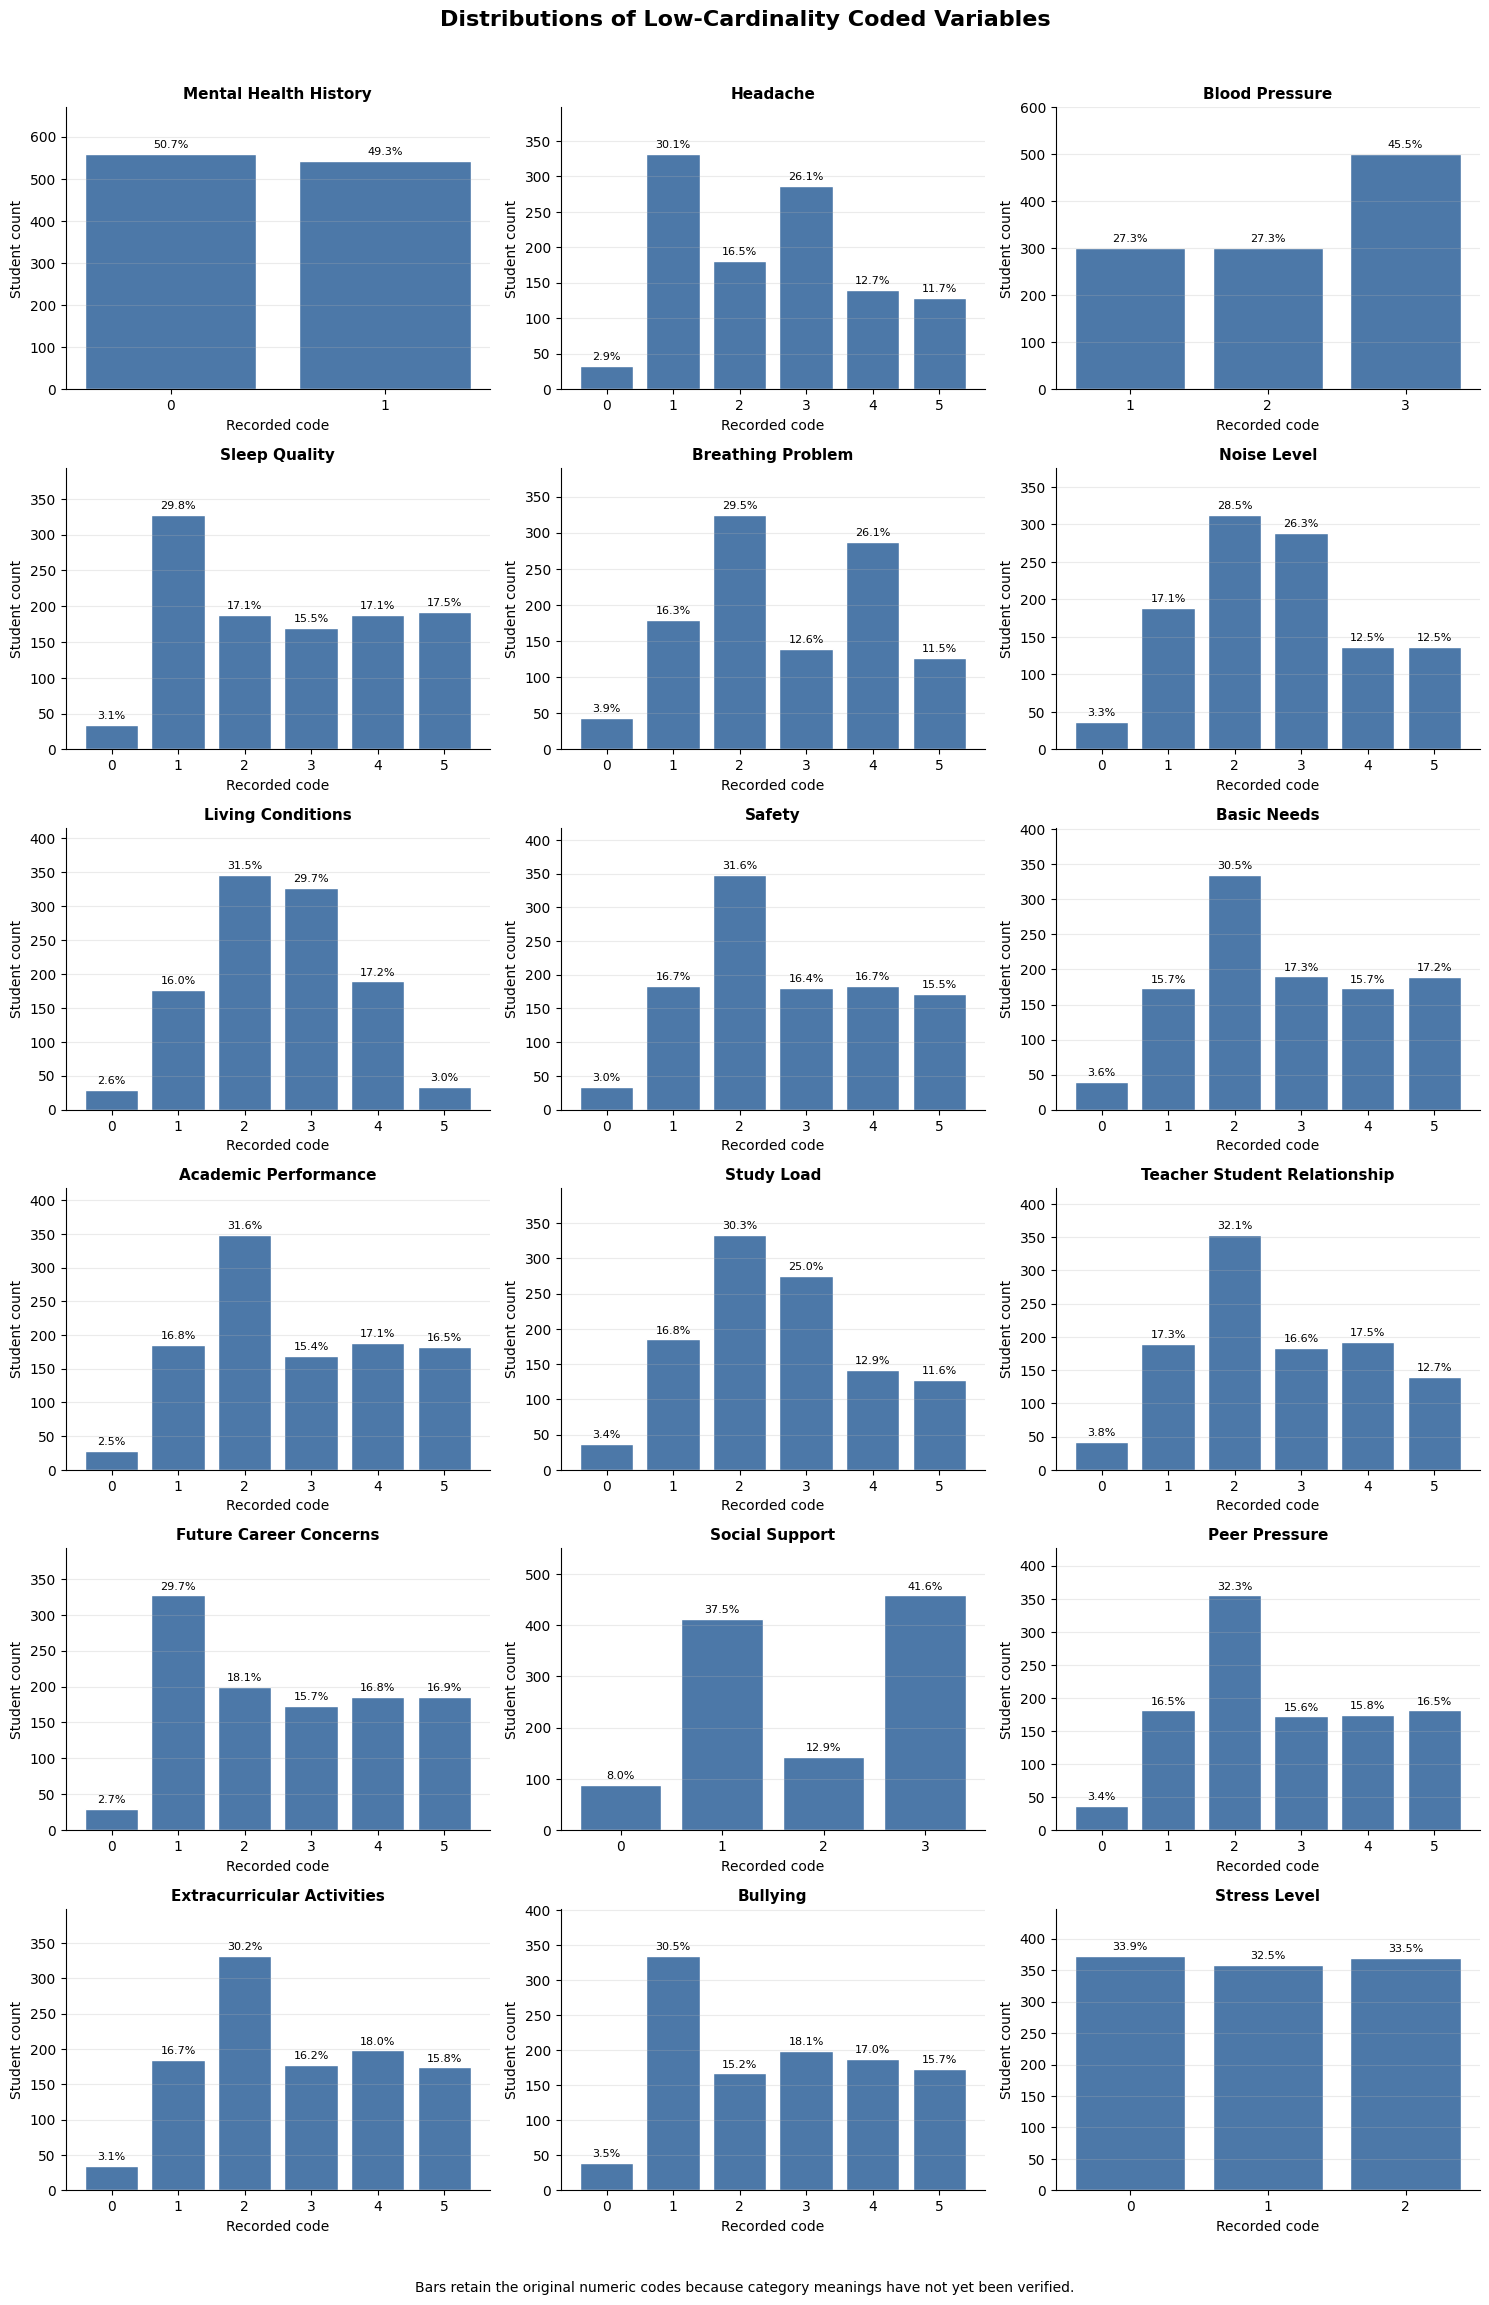

In [7]:
import math
import matplotlib.pyplot as plt

# Select variables with six or fewer recorded values.
coded_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) <= 6
]

n_columns = 3
n_rows = math.ceil(len(coded_columns) / n_columns)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(15, 3.8 * n_rows),
    squeeze=False,
)

for ax, column in zip(axes.flat, coded_columns):
    counts = (
        df[column]
        .value_counts(dropna=False)
        .sort_index()
    )

    category_labels = [
        "Missing" if pd.isna(value) else str(value)
        for value in counts.index
    ]

    bars = ax.bar(
        category_labels,
        counts.values,
        color="#4C78A8",
        edgecolor="white",
    )

    percentage_labels = [
        f"{count / len(df):.1%}"
        for count in counts.values
    ]

    ax.bar_label(
        bars,
        labels=percentage_labels,
        padding=3,
        fontsize=8,
    )

    ax.set_title(
        column.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Recorded code")
    ax.set_ylabel("Student count")
    ax.set_ylim(0, counts.max() * 1.20)
    ax.grid(axis="y", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Remove empty subplot spaces.
for ax in axes.flat[len(coded_columns):]:
    ax.remove()

fig.suptitle(
    "Distributions of Low-Cardinality Coded Variables",
    fontsize=16,
    fontweight="bold",
    y=1.002,
)

fig.text(
    0.5,
    0.001,
    (
        "Bars retain the original numeric codes because category "
        "meanings have not yet been verified."
    ),
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

In [8]:
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

output_path = FIGURES_DIR / "coded-variable-distributions.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

output_path.relative_to(PROJECT_ROOT)

WindowsPath('figures/coded-variable-distributions.png')

### What the distribution figure tells us

The figure is a **univariate** view: each panel describes one variable separately. It reveals that the stress classes and mental-health-history groups are close to balanced, while several rating variables concentrate around particular codes. It does not yet show which factors relate to stress; that requires comparing a predictor with the outcome.

## 4. Verify and label the key encodings

The CSV proves that numeric codes are present, but an external source is needed to justify their meanings.

### Encoding evidence

| Variable | Code mapping used | Evidence and interpretation |
|---|---|---|
| `mental_health_history` | `0` = No history reported; `1` = History reported | The dataset authors count `mental_health_history == 1` as students with a mental-health history. Since the field is binary, `0` is the complementary category. |
| `stress_level` | `0` = Low; `1` = Medium; `2` = High | Published work using the same dataset describes three ordered stress classes—low, medium, and high—and identifies class `2` as high stress. |

The original Kaggle page does not provide the full survey instrument or a complete item-level codebook. We therefore record the mapping and its evidence explicitly rather than treating it as self-evident. Other coded variables remain unlabeled until their meanings are verified.

In [9]:
encoding_spec = {
    "mental_health_history": {
        0: "No history reported",
        1: "History reported",
    },
    "stress_level": {
        0: "Low",
        1: "Medium",
        2: "High",
    },
}

# Validate the mapping instead of silently assuming every value is known.
for column, mapping in encoding_spec.items():
    observed_codes = {
        int(value) for value in df[column].dropna().unique()
    }
    documented_codes = set(mapping)
    unexpected_codes = observed_codes - documented_codes

    print(f"{column}: {sorted(observed_codes)}")

    assert not unexpected_codes, (
        f"{column} contains undocumented codes: {unexpected_codes}"
    )

mental_health_history: [0, 1]
stress_level: [0, 1, 2]


The validation cell is a safety check. It confirms that every observed value belongs to the documented mapping. If a future data version contains an unexpected code, the assertion stops the notebook instead of silently converting that value to a missing label.

In [10]:
df_analysis = df.copy()

# Add readable columns while preserving the original numeric codes.
df_analysis["mental_health_history_label"] = (
    df_analysis["mental_health_history"]
    .map(encoding_spec["mental_health_history"])
)
df_analysis["mental_health_history_label"] = pd.Categorical(
    df_analysis["mental_health_history_label"],
    categories=["No history reported", "History reported"],
)

df_analysis["stress_level_label"] = (
    df_analysis["stress_level"]
    .map(encoding_spec["stress_level"])
)
df_analysis["stress_level_label"] = pd.Categorical(
    df_analysis["stress_level_label"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)

df_analysis[
    [
        "mental_health_history",
        "mental_health_history_label",
        "stress_level",
        "stress_level_label",
    ]
].head(10)

,mental_health_history,mental_health_history_label,stress_level,stress_level_label
0,0,No history reported,1,Medium
1,1,History reported,2,High
2,1,History reported,1,Medium
3,1,History reported,2,High
4,0,No history reported,1,Medium
5,1,History reported,2,High
6,0,No history reported,0,Low
7,1,History reported,2,High
8,1,History reported,1,Medium
9,0,No history reported,1,Medium


The readable columns are added to `df_analysis`; the original numeric columns remain available. `stress_level_label` is declared as an **ordered categorical variable**, because Low < Medium < High. This matters later when we choose summaries, visualizations, and models.

In [11]:
variable_types = {
    "mental_health_history": "Binary categorical predictor",
    "stress_level": "Ordered categorical outcome",
}

codebook_rows = []

for variable, mapping in encoding_spec.items():
    counts = df[variable].value_counts().sort_index()

    for code, meaning in mapping.items():
        count = int(counts.get(code, 0))
        codebook_rows.append({
            "variable": variable,
            "variable_type": variable_types[variable],
            "code": code,
            "meaning": meaning,
            "count": count,
            "percent": round(count / len(df) * 100, 1),
        })

encoding_table = pd.DataFrame(codebook_rows)
encoding_table

,variable,variable_type,code,meaning,count,percent
0,mental_health_history,Binary categorical predictor,0,No history reported,558,50.7
1,mental_health_history,Binary categorical predictor,1,History reported,542,49.3
2,stress_level,Ordered categorical outcome,0,Low,373,33.9
3,stress_level,Ordered categorical outcome,1,Medium,358,32.5
4,stress_level,Ordered categorical outcome,2,High,369,33.5


### Encoded-variable summary

Both variables are close to balanced overall:

- Mental-health history: 558 students (50.7%) report no history and 542 (49.3%) report a history.
- Stress level: 373 students (33.9%) are Low, 358 (32.5%) are Medium, and 369 (33.5%) are High.

Balance is useful for comparison because every group has substantial data, but it says nothing yet about the relationship between the variables.

## 5. Compare stress level by mental-health history

A 100% stacked bar chart answers a conditional question: **within each mental-health-history group, what percentage of students belongs to each stress category?**

Each bar totals 100%. Therefore, compare colors **between bars**, rather than comparing the total heights of the bars.

In [12]:
def plot_stress_by(data, predictor, outcome):
    """Plot outcome percentages within each predictor category."""
    percentage_table = (
        pd.crosstab(
            data[predictor],
            data[outcome],
            normalize="index",
            dropna=False,
        )
        .mul(100)
    )

    predictor_order = list(data[predictor].cat.categories)
    outcome_order = list(data[outcome].cat.categories)

    percentage_table = percentage_table.reindex(
        index=predictor_order,
        columns=outcome_order,
        fill_value=0,
    )

    category_counts = (
        data[predictor]
        .value_counts(sort=False)
        .reindex(predictor_order)
    )

    ax = percentage_table.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5.5),
        width=0.72,
        color=["#4C78A8", "#F58518", "#54A24B"],
    )

    for container in ax.containers:
        labels = [
            f"{value:.1f}%" if value >= 5 else ""
            for value in container.datavalues
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=9,
            color="white",
            fontweight="bold",
        )

    ax.set_title(
        "Stress-Level Composition by Mental-Health History",
        fontweight="bold",
    )
    ax.set_xlabel("Mental-health history")
    ax.set_ylabel("Students within history group (%)")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(
        [
            f"{value}\n(n={int(category_counts.loc[value])})"
            for value in percentage_table.index
        ],
        rotation=0,
    )
    ax.legend(
        title="Stress level",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return percentage_table.round(1)

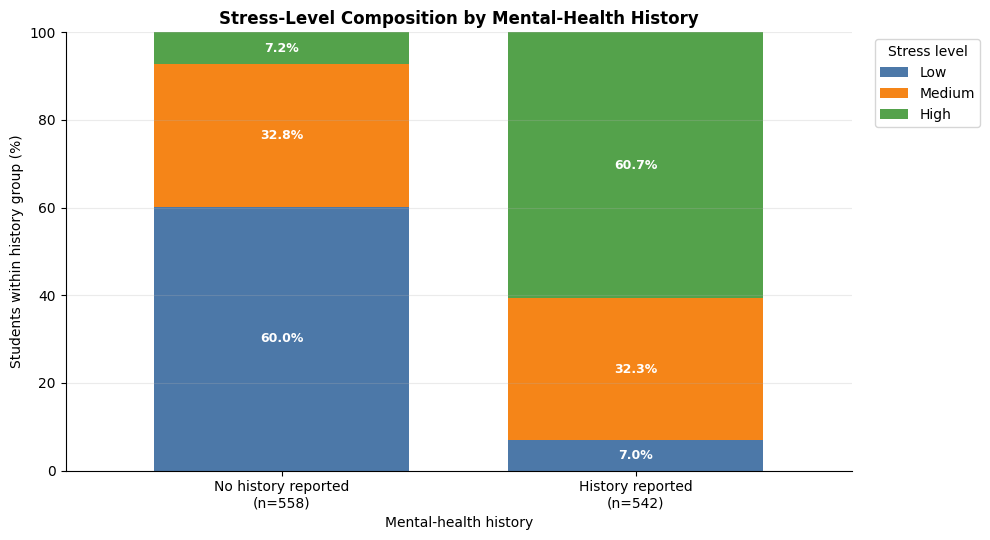

stress_level_label,Low,Medium,High
mental_health_history_label,,,
No history reported,60.0,32.8,7.2
History reported,7.0,32.3,60.7


In [13]:
stress_by_history = plot_stress_by(
    df_analysis,
    predictor="mental_health_history_label",
    outcome="stress_level_label",
)

stress_by_history

### Reading the comparison

- Among students with **no reported history**, 60.0% have Low stress, 32.8% Medium stress, and 7.2% High stress.
- Among students with a **reported history**, 7.0% have Low stress, 32.3% Medium stress, and 60.7% High stress.
- The Medium category is nearly unchanged between groups. The major difference is a reversal of the Low and High proportions.

The code below summarizes the size of the High-stress difference. A percentage-point difference and a proportion ratio describe different aspects of the same comparison.

In [14]:
history_stress_counts = pd.crosstab(
    df_analysis["mental_health_history_label"],
    df_analysis["stress_level_label"],
    dropna=False,
)

history_stress_percent = history_stress_counts.div(
    history_stress_counts.sum(axis=1),
    axis=0,
).mul(100)

high_no_history = history_stress_percent.loc[
    "No history reported", "High"
]
high_with_history = history_stress_percent.loc[
    "History reported", "High"
]

association_summary = pd.DataFrame({
    "metric": [
        "High stress: no history reported",
        "High stress: history reported",
        "High-stress percentage-point difference",
        "High-stress proportion ratio",
    ],
    "value": [
        f"{high_no_history:.1f}%",
        f"{high_with_history:.1f}%",
        f"{high_with_history - high_no_history:.1f} percentage points",
        f"{high_with_history / high_no_history:.1f}x",
    ],
})

association_summary

,metric,value
0,High stress: no history reported,7.2%
1,High stress: history reported,60.7%
2,High-stress percentage-point difference,53.5 percentage points
3,High-stress proportion ratio,8.5x


## 6. Early-warning direction

The application will aim to flag elevated stress risk using students' academic, social, and environmental circumstances. Its purpose is supportive early attention—not diagnosis or automatic decision-making.

### Limitation

This dataset has no time or follow-up information, so it cannot prove that we are predicting **future** stress. The first version is more accurately described as a **context-based indicator of current stress risk**.

The documentation also does not explain exactly how `stress_level` was created. If it was calculated from other variables, using those same variables could produce misleadingly high model performance.

### Feature strategy

| Group | Examples | Planned use |
|---|---|---|
| Contextual factors | study load, bullying, social support, noise level | Main early-warning model |
| Proximal states | anxiety, depression, headache, sleep quality | Later comparison model |
| Sensitive history | mental-health history | Evaluate separately and cautiously |

The next part will examine how the contextual factors relate to stress before we train any model.

## 7. Contextual-factor exploratory analysis

Spearman correlation is used here as a descriptive measure because the predictors are recorded as ordered codes. Statistical significance and uncertainty are evaluated in the next phase.

In [15]:
contextual_features = [
    "study_load",
    "bullying",
    "social_support",
    "noise_level",
    "peer_pressure",
    "teacher_student_relationship",
    "living_conditions",
    "safety",
    "basic_needs",
    "future_career_concerns",
    "extracurricular_activities",
    "academic_performance",
]

context_associations = (
    df[contextual_features + ["stress_level"]]
    .corr(method="spearman")["stress_level"]
    .drop("stress_level")
    .rename("spearman_rho")
    .to_frame()
    .assign(abs_rho=lambda table: table["spearman_rho"].abs())
    .sort_values("abs_rho", ascending=False)
    .drop(columns="abs_rho")
)

context_associations.round(3)

,spearman_rho
bullying,0.760
future_career_concerns,0.754
academic_performance,-0.728
basic_needs,-0.719
safety,-0.714
extracurricular_activities,0.702
noise_level,0.696
peer_pressure,0.694
teacher_student_relationship,-0.687
study_load,0.666


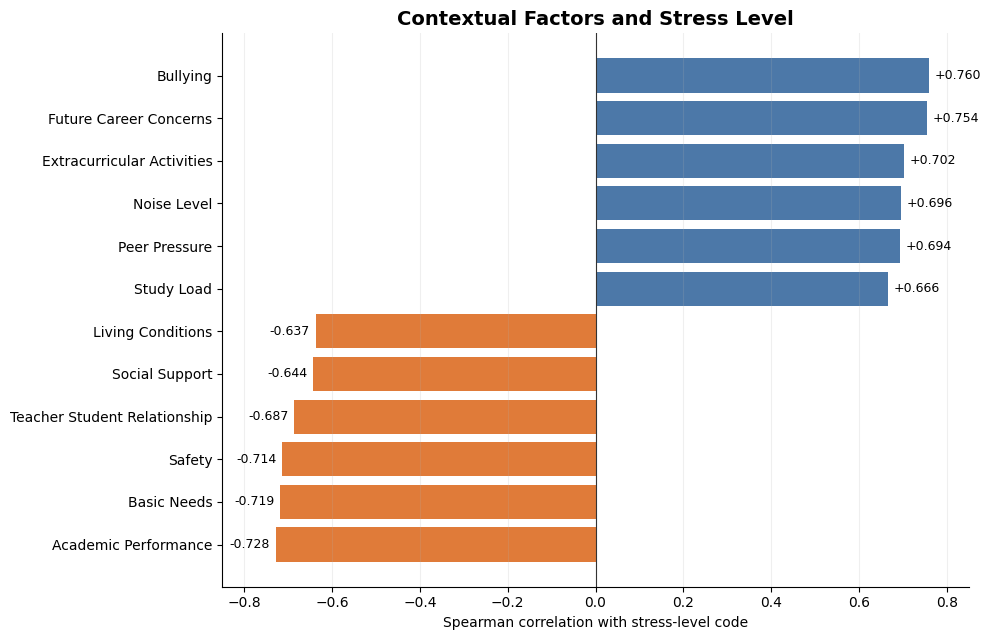

In [16]:
plot_data = context_associations.sort_values("spearman_rho")
readable_labels = [
    label.replace("_", " ").title()
    for label in plot_data.index
]
colors = [
    "#4C78A8" if value > 0 else "#E07B39"
    for value in plot_data["spearman_rho"]
]

association_fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(
    readable_labels,
    plot_data["spearman_rho"],
    color=colors,
)

ax.axvline(0, color="#333333", linewidth=0.8)
ax.bar_label(
    bars,
    labels=[f"{value:+.3f}" for value in plot_data["spearman_rho"]],
    padding=4,
    fontsize=9,
)
ax.set_xlim(-0.85, 0.85)
ax.set_xlabel("Spearman correlation with stress-level code")
ax.set_title(
    "Contextual Factors and Stress Level",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="x", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

association_fig.tight_layout()
association_output = FIGURES_DIR / "contextual-feature-correlations.png"
association_fig.savefig(association_output, dpi=300, bbox_inches="tight")
plt.show()

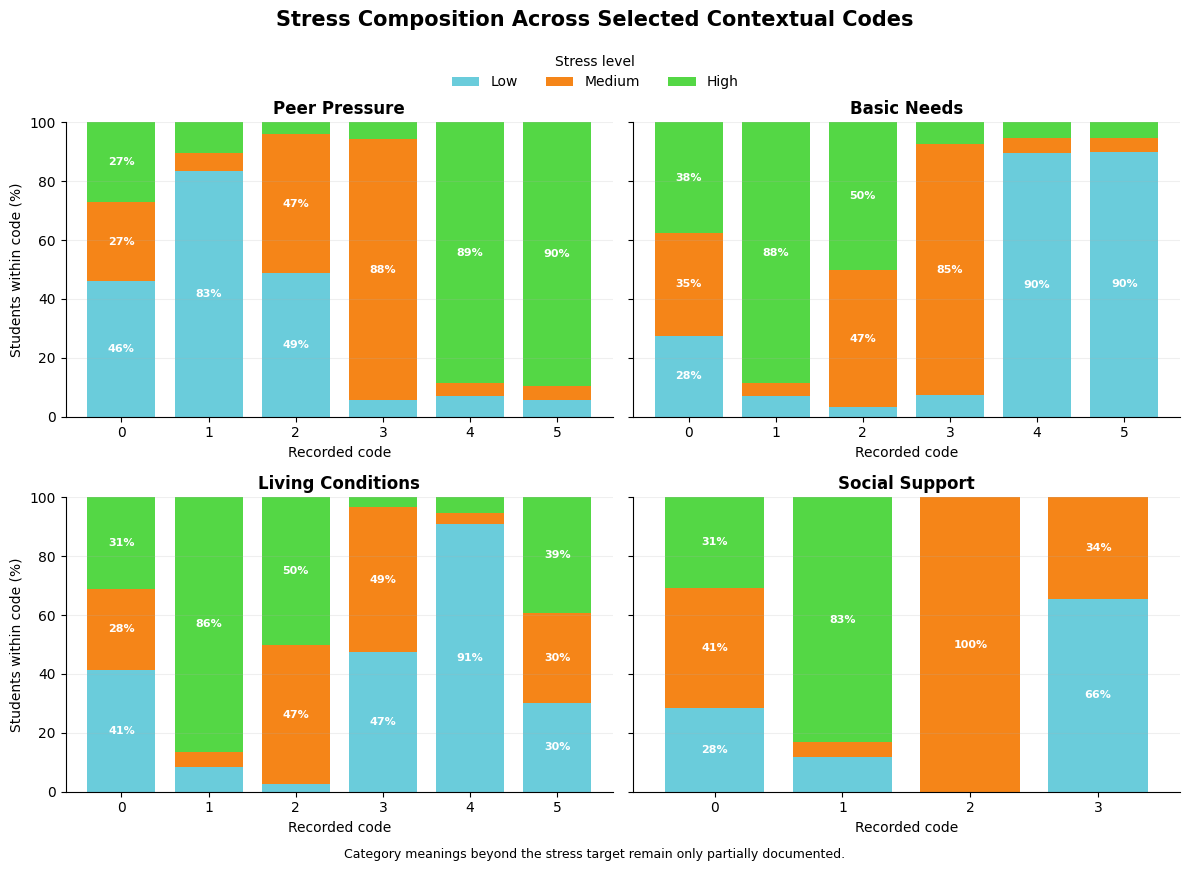

In [19]:
selected_context_features = [
    "peer_pressure",
    "basic_needs",
    "living_conditions",
    "social_support",
]

composition_fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharey=True,
)

stress_order = ["Low", "Medium", "High"]
stress_colors = ["#6ACCDB", "#F58518", "#54D745"]

for ax, feature in zip(axes.flat, selected_context_features):
    table = (
        pd.crosstab(
            df_analysis[feature],
            df_analysis["stress_level_label"],
            normalize="index",
            dropna=False,
        )
        .mul(100)
        .reindex(columns=stress_order, fill_value=0)
    )

    table.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=stress_colors,
        width=0.78,
        legend=False,
    )

    for container in ax.containers:
        labels = [
            f"{value:.0f}%" if value >= 15 else ""
            for value in container.datavalues
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )

    ax.set_title(feature.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Recorded code")
    ax.set_ylabel("Students within code (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
composition_fig.legend(
    handles,
    labels,
    title="Stress level",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
)
composition_fig.suptitle(
    "Stress Composition Across Selected Contextual Codes",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
composition_fig.text(
    0.5,
    -0.01,
    "Category meanings beyond the stress target remain only partially documented.",
    ha="center",
    fontsize=9,
)
composition_fig.tight_layout()

composition_output = FIGURES_DIR / "selected-context-stress-composition.png"
composition_fig.savefig(composition_output, dpi=300, bbox_inches="tight")
plt.show()

### Findings

- Bullying (`ρ = 0.760`) and future-career concerns (`ρ = 0.754`) have the strongest positive associations.
- Academic performance (`ρ = −0.728`), basic needs (`ρ = −0.719`), and safety (`ρ = −0.714`) have the strongest negative associations.
- Peer pressure is strongly positive (`ρ = 0.694`); social support (`ρ = −0.644`) and living conditions (`ρ = −0.637`) are negative.
- All contextual relationships are unusually strong and several code levels nearly separate the stress classes. The project will continue as a portfolio prototype, but real-world validity remains unverified.

## 8. Current results

- The dataset has 1,100 records, 21 integer-coded variables, no missing values, and no duplicate rows.
- Stress classes and mental-health-history groups are approximately balanced.
- High stress occurs in 60.7% of the history-reported group and 7.2% of the no-history group.
- Contextual variables show strong monotonic relationships with stress (`|ρ| = 0.637–0.760`).
- The repeated, clean separation of stress classes suggests that prediction may be unusually easy in this dataset; external validity is not established.

**Next phase:** statistical inference, effect sizes, and uncertainty.